In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
## credit-card-fraud-detection dataset from kaggle.
df = pd.read_csv("creditcard.csv")

X = df.drop(columns=["Class"]).values.astype(np.float64)  # Time, V1..V28, Amount
y = df["Class"].values.astype(np.float64)                 # 0/1

print("Shape X:", X.shape, " | Shape y:", y.shape)
print("Fraud count:", int(y.sum()), "  Fraud %:", 100*y.mean())

Shape X: (284807, 30)  | Shape y: (284807,)
Fraud count: 492   Fraud %: 0.1727485630620034


In [3]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

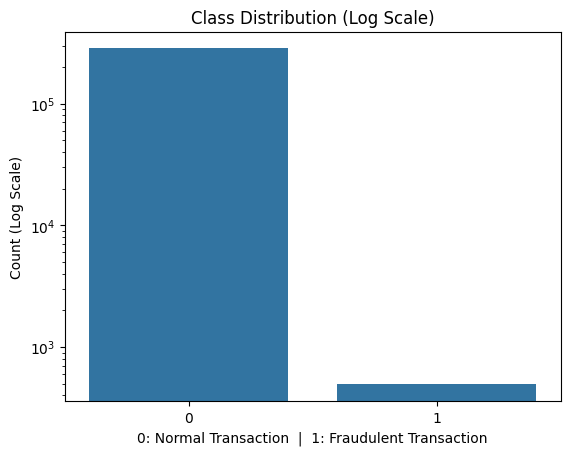

In [5]:
import seaborn as sns
sns.countplot(x='Class', data=df)
plt.yscale('log') 
plt.title("Class Distribution (Log Scale)")
plt.xlabel("0: Normal Transaction  |  1: Fraudulent Transaction")
plt.ylabel("Count (Log Scale)")

plt.show()

In [6]:
corr=df.corr()
corr.shape

(31, 31)

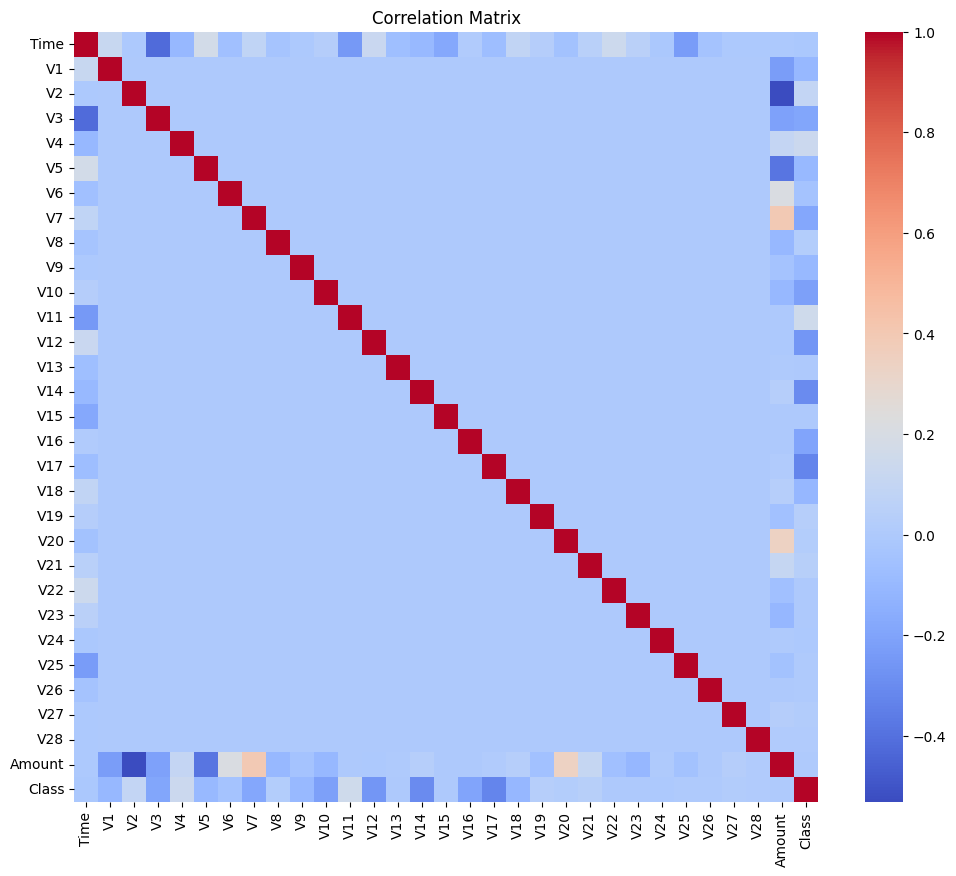

In [7]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot_kws={'size':20})
plt.title("Correlation Matrix")
plt.show()

In [8]:
fraud=df[df['Class'] == 1]
non_fraud=df[df['Class'] == 0]
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0
mean,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0
std,47835.365138,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,3.869304,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0
min,406.000000,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0
25%,41241.500000,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,0.041787,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0
50%,75568.500000,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.592146,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0
75%,128483.000000,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,1.244611,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0
max,170348.000000,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,27.202839,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0


In [9]:
# 80% trainval, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

# from trainval, take 20% as val => overall val=16% of full data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42)

In [10]:
# ZSCORE NORMALIZATION
# standardizing the data
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
eps = 1e-15

X_train_s = (X_train - mu) / (sigma + eps)
X_val_s = (X_val - mu) / (sigma + eps)
X_test_s = (X_test - mu) / (sigma + eps)
print("Standardised shapes:")
print(X_train_s.shape)
print(X_val_s.shape)
print(X_test_s.shape)

Standardised shapes:
(182276, 30)
(45569, 30)
(56962, 30)


In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logloss(y, p):
    p = np.clip(p, eps, 1 - eps) # Avoid log(0) by clipping probabilities
    losses = -(y*np.log(p) + (1-y)*np.log(1-p)) 
    
    return np.mean(losses)

def compute_class_weights(y):
    # Balanced weights: w1=N/(2N1), w0=N/(2N0)
    n = len(y)
    n1 = np.sum(y == 1)
    n0 = n - n1
    w1 = n / (2 * max(1.0, n1))
    w0 = n / (2 * max(1.0, n0))
    return float(w0), float(w1)

# TRAINING

In [12]:
def train_logreg_with_val(X_train, y_train, X_val, y_val, lr=0.01, epochs=200, weighted_loss=False):
    
    n, d = X_train.shape
    w = np.zeros(d)
    b = 0.0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(1, epochs + 1): #LOOP STARTS FROM 1 TO AVOID ZERO DIVISION IN LOGLOSS CALCULATION TO COMPUTE CLASS WEIGHTS
        # ---- forward pass ----
        z = X_train @ w + b
        p = sigmoid(z)
        
        # ---- gradients (traditional) ----
        error = (p - y_train)
        
        if weighted_loss:
            w0, w1 = compute_class_weights(y_train)
        else:
            w0, w1 = 1.0, 1.0
        
        ws = np.where(y_train==1, w1, w0) # if the sample is fraud (y=1) use a big w1 weight, else use w0 a tiny weight for non-fraud samples.
        weighted_error = ws * error
        dw = (X_train.T @ weighted_error) / n
        db = np.mean(weighted_error)
        
        
        # ---- update ----
        w -= lr * dw
        b -= lr * db

        # ---- compute losses for train and val ----
        train_loss = logloss(y_train, sigmoid(X_train @ w + b))
        val_loss = logloss(y_val, sigmoid(X_val @ w + b))
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        if (epoch % 5 == 0):
            print(f"epoch:{epoch:4d} train_logloss={train_loss:.6f} val_logloss={val_loss:.6f}")
            #WHEN THE CODE SEES THE TRAINING LOSS IS GOING DOWN AND MODEL LOSS IS GOING UP, THE MODEL IS OVERFITTING AND STOP THE LOOP.
    return w, b, train_losses, val_losses

In [13]:
w, b, train_losses, val_losses = train_logreg_with_val(
    X_train_s, y_train, X_val_s, y_val,
    lr=0.05, epochs=1000, weighted_loss=True) # weighted loss = true activates the compute weight class function to handle class imbalance, and checks each and every anomanly fraud case

epoch:   5 train_logloss=0.670898 val_logloss=0.670817
epoch:  10 train_logloss=0.648719 val_logloss=0.648631
epoch:  15 train_logloss=0.627516 val_logloss=0.627418
epoch:  20 train_logloss=0.607328 val_logloss=0.607214
epoch:  25 train_logloss=0.588146 val_logloss=0.588017
epoch:  30 train_logloss=0.569945 val_logloss=0.569798
epoch:  35 train_logloss=0.552687 val_logloss=0.552520
epoch:  40 train_logloss=0.536327 val_logloss=0.536140
epoch:  45 train_logloss=0.520820 val_logloss=0.520613
epoch:  50 train_logloss=0.506120 val_logloss=0.505892
epoch:  55 train_logloss=0.492181 val_logloss=0.491933
epoch:  60 train_logloss=0.478959 val_logloss=0.478691
epoch:  65 train_logloss=0.466413 val_logloss=0.466124
epoch:  70 train_logloss=0.454501 val_logloss=0.454193
epoch:  75 train_logloss=0.443187 val_logloss=0.442859
epoch:  80 train_logloss=0.432433 val_logloss=0.432086
epoch:  85 train_logloss=0.422207 val_logloss=0.421841
epoch:  90 train_logloss=0.412476 val_logloss=0.412091
epoch:  95

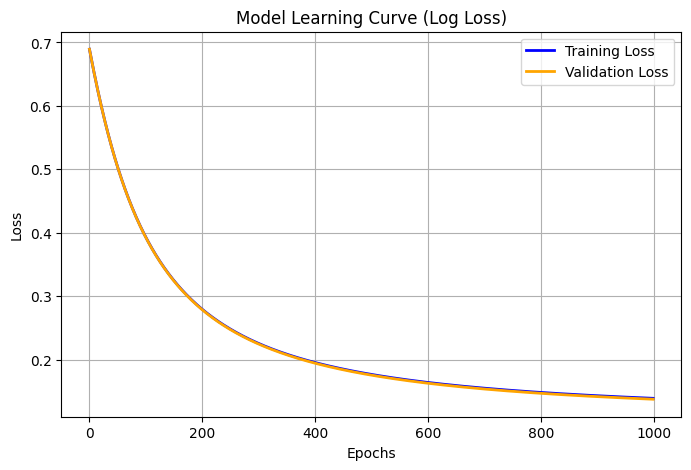

In [14]:
# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=2)

# Add titles and labels
plt.title('Model Learning Curve (Log Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Display the graph
plt.show()

Raw Confusion Matrix Array:
 [[53282  3582]
 [    7    91]]

--- Classification Report ---
              precision    recall  f1-score   support

   Legit (0)       1.00      0.94      0.97     56864
   Fraud (1)       0.02      0.93      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.93      0.51     56962
weighted avg       1.00      0.94      0.97     56962



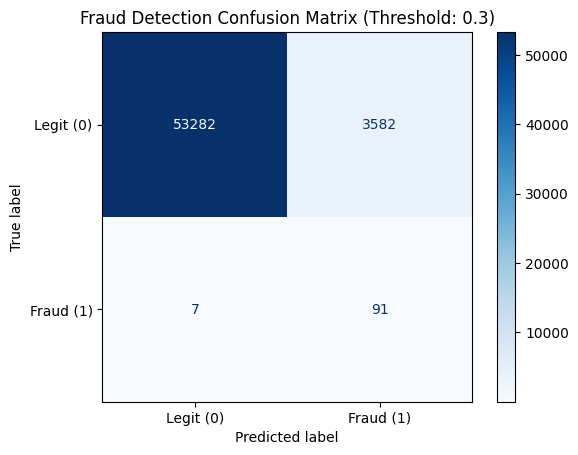

In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# compute test probabilities (ensure p_test exists before using it)
z_test = X_test_s @ w + b
p_test = sigmoid(z_test)

# 1. Apply your chosen threshold (e.g., 0.3 for fraud detection)
threshold = 0.3
y_pred_probs = p_test  # use the probabilities computed for the test set
y_pred = (y_pred_probs >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Raw Confusion Matrix Array:\n", cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Legit (0)', 'Fraud (1)']))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', values_format='d') # 'd' ensures whole numbers are displayed
plt.title(f"Fraud Detection Confusion Matrix (Threshold: {threshold})")
plt.show()

Final Test AUC Score: 0.9822


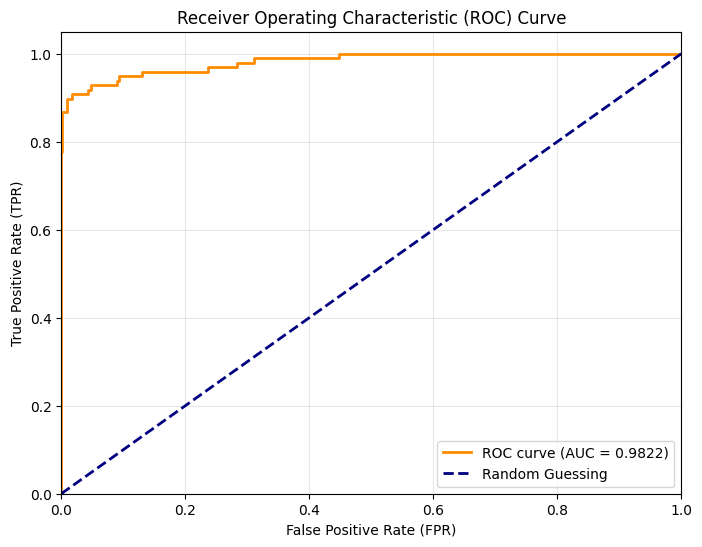

In [16]:
# 1. Generate probability predictions for the Test Set
from sklearn.metrics import auc, roc_curve


z_test = X_test_s @ w + b
p_test = sigmoid(z_test)

# 2. Calculate FPR, TPR, and the exact AUC score
fpr, tpr, thresholds = roc_curve(y_test, p_test)
roc_auc = auc(fpr, tpr)

print(f"Final Test AUC Score: {roc_auc:.4f}")

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')

# This is the "dumb guessing" baseline (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Guessing')

# 4. Format the graph to look clean and professional
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)



# Display the graph
plt.show()

In [17]:
import numpy as np

# Calculate the J score for every single threshold tested in the ROC curve
j_scores = tpr - fpr


best_index = np.argmax(j_scores) # Index of the highest score
best_threshold = thresholds[best_index]

print(f"The mathematically optimal threshold is: {best_threshold:.4f}")

# --- Example of how this works for a single transaction ---
example_probability = p_test[0] # Taking the first transaction in the test set
print(f"Raw Model Probability: {example_probability:.4f}")

if example_probability >= best_threshold:
    print("ACTION: Transaction BLOCKED. Flagged as Fraud (1).")
else:
    print("ACTION: Transaction APPROVED. Flagged as Normal (0).")

The mathematically optimal threshold is: 0.5547
Raw Model Probability: 1.0000
ACTION: Transaction BLOCKED. Flagged as Fraud (1).
